# 04 · Pipeline de Mensageria — Backtest v3 + Estado Atual

**Objetivo:** combinar saídas dos notebooks 01 e 02, rodar o `trigger_engine.py` v3.0
(nova hierarquia RISCO / CRÍTICO / EMERGENCIAL) sobre o histórico completo (backtest) e avaliar estado atual.

| Etapa | Descrição |
|---|---|
| A | Carregar e preparar dados (01 + 02), montar df_hourly com DateTimeIndex |
| B | Backtest histórico: ciclo a ciclo, dia a dia |
| C | Linha do tempo — gatilhos × trocas reais |
| D | Estado atual — avaliação com os dados mais recentes |
| E | (Opcional) Escrever no SharePoint |
| F | Envio retroativo: backtest 2026 → SharePoint |

In [1]:
import sys, json, warnings, tempfile
from pathlib import Path
from datetime import datetime
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.trigger_engine import TriggerEngine, TriggerEvent

# ── Configurações ────────────────────────────────────────────────────────────
ARQUIVO_TROCAS    = 'troca_modulo.csv'
COLUNA_DATA_TROCA = 'Data-base do inicio'
MAQUINA           = 'FB14'
LIST_NAME         = 'Gatilhos_Selagem'
ESCREVER_SP       = False   # True → escreve no SharePoint (requer sharepoint.ev)
# ─────────────────────────────────────────────────────────────────────────────
print('Módulos OK')

Módulos OK


## Etapa A — Carregar e preparar df_hourly

In [2]:
v1 = pd.read_csv('01_vida_rul.csv',     parse_dates=['Timestamp'])
v2 = pd.read_csv('02_sinais_forca.csv', parse_dates=['Timestamp'])

v1['Timestamp'] = pd.to_datetime(v1['Timestamp'], utc=True)
v2['Timestamp'] = pd.to_datetime(v2['Timestamp'], utc=True)

# Merge: pega Media de v2 (recalculada) + colunas v2 para referência visual
df = v1.merge(
    v2[['Timestamp', 'Media', 'Delta_AB',
        'slope_Media_7d', 'mean_3d', 'mean_14d',
        'signal_score', 'proj_48h', 'p_risk']],
    on='Timestamp', how='left'
)

# DateTimeIndex — necessário para o trigger_engine
df = df.set_index('Timestamp').sort_index()

# Trocas
tc = pd.read_csv(ARQUIVO_TROCAS, parse_dates=[COLUNA_DATA_TROCA])
tc = tc.sort_values(COLUNA_DATA_TROCA).reset_index(drop=True)
troca_dates = pd.to_datetime(tc[COLUNA_DATA_TROCA]).dt.tz_localize('UTC').tolist()

print(f'df_hourly: {len(df)} linhas  |  {df.index.min().date()} -> {df.index.max().date()}')
print(f'Trocas   : {len(troca_dates)}  (ultima: {troca_dates[-1].date()})')
print(f'Colunas  : {list(df.columns)}')


df_hourly: 3257 linhas  |  2022-06-27 -> 2026-05-26
Trocas   : 15  (ultima: 2026-05-20)
Colunas  : ['horas_desde_troca', 'ciclo_id', 'score_weibull', 'score_roll7d', 'rul_p10', 'rul_p50', 'rul_p90', 'Media', 'Delta_AB', 'slope_Media_7d', 'mean_3d', 'mean_14d', 'signal_score', 'proj_48h', 'p_risk']


## Etapa B — Backtest histórico

Para cada ciclo histórico, simula o trigger engine dia a dia.  
Um arquivo de estado temporário é usado por ciclo para evitar interferência.

In [ ]:
all_events = []

state_path = Path(tempfile.mktemp(suffix='.json'))

# ── Ciclos históricos completos ───────────────────────────────────────────────
for i, (t_ini, t_fim) in enumerate(zip(troca_dates[:-1], troca_dates[1:])):
    ciclo_df = df[(df.index >= t_ini) & (df.index < t_fim)]
    if ciclo_df.empty:
        continue

    if state_path.exists():
        state_path.unlink()
    engine = TriggerEngine(MAQUINA, state_path)

    dias = pd.DatetimeIndex(
        sorted({ts.normalize() for ts in ciclo_df.index})
    )

    for day in dias:
        df_ate_hoje = df[df.index <= day + pd.Timedelta(hours=23, minutes=59)]
        if df_ate_hoje.empty:
            continue
        try:
            events = engine.evaluate(
                df_ate_hoje,
                troca_date  = t_ini.to_pydatetime(),
                sp_client   = None,
                today       = day,
                troca_dates = troca_dates,
            )
        except Exception as exc:
            print(f'  [ERRO] ciclo {i} dia {day.date()}: {exc}')
            continue

        for ev in events:
            all_events.append({
                'ciclo_id'       : i,
                'troca_ini'      : t_ini.date(),
                'troca_fim'      : t_fim.date(),
                'data_disparo'   : day.date(),
                'gatilho'        : ev.gatilho,
                'severidade'     : ev.severidade,
                'idade_dias'     : ev.idade_maintacker,
                'evento_no_ciclo': ev.evento_no_ciclo,
                'p_risk'         : ev.score_atual,
                'signal_score'   : ev.signal_score,
                'age_risk'       : ev.age_risk,
                'slope_7d'       : ev.slope_forca_7d,
                'mean_3d'        : ev.forca_minima_3d,
                'proj_48h'       : ev.proj_48h,
                'antecedencia_d' : (t_fim.date() - day.date()).days,
            })

if state_path.exists():
    state_path.unlink()

# ── Ciclo atual — usar state_fb14.json como fonte de verdade ─────────────────
# Re-simular com estado zerado gera disparos fantasma: os cooldowns do ciclo
# anterior não existem no estado temporário, e a janela min_3d de 3 dias
# persiste leituras abaixo de 800 por múltiplos dias.
_t_ini_atual   = troca_dates[-1]
_ciclo_id_atual = len(troca_dates) - 1

_SEVER_MAP = {
    'RISCO':      'INFO',   'REVISAO':    'INFO',
    'AMARELO':    'MEDIA',  'CRITICO':    'ALTA',
    'EMERGENCIAL':'CRITICA','RED':        'ALTA',
}
_GATILHO_KEYS = {
    'RISCO': 'risco', 'AMARELO': 'amarelo', 'CRITICO': 'critico',
    'EMERGENCIAL': 'emergencial', 'RED': 'red', 'REVISAO': 'revisao',
}

_state_real_path = Path('state_fb14.json')
_n_atual = 0
if _state_real_path.exists():
    with open(_state_real_path) as _f:
        _state_json = json.load(_f)
    for _gat, _key in _GATILHO_KEYS.items():
        _entry = _state_json.get(_key, {})
        _lf    = _entry.get('last_fired')
        if not _lf:
            continue
        _lf_ts = pd.Timestamp(_lf).tz_convert('UTC')
        if _lf_ts < _t_ini_atual:
            continue
        _day  = _lf_ts.normalize()
        _age  = int((_day - _t_ini_atual).days)
        _snap = df[df.index <= _day + pd.Timedelta(hours=23, minutes=59)]
        all_events.append({
            'ciclo_id'       : _ciclo_id_atual,
            'troca_ini'      : _t_ini_atual.date(),
            'troca_fim'      : None,
            'data_disparo'   : _day.date(),
            'gatilho'        : _gat,
            'severidade'     : _SEVER_MAP[_gat],
            'idade_dias'     : _age,
            'evento_no_ciclo': 1,
            'p_risk'         : float(_snap['p_risk'].iloc[-1])       if not _snap.empty else None,
            'signal_score'   : float(_snap['signal_score'].iloc[-1]) if not _snap.empty else None,
            'age_risk'       : None,
            'slope_7d'       : None,
            'mean_3d'        : float(_snap['mean_3d'].iloc[-1])      if not _snap.empty else None,
            'proj_48h'       : None,
            'antecedencia_d' : None,
        })
        _n_atual += 1
    print(f'  ★ Ciclo atual ({_t_ini_atual.date()} → hoje): '
          f'{_n_atual} evento(s) real(is) lido(s) do state_fb14.json')
else:
    print('  ★ Ciclo atual: state_fb14.json não encontrado.')

# ── Consolidar ────────────────────────────────────────────────────────────────
eventos_df = pd.DataFrame(all_events).sort_values(by='troca_ini', ascending=False)
print(f'\nTotal de eventos (backtest + ciclo atual) : {len(eventos_df)}')
if not eventos_df.empty:
    print()
    print('Por tipo de gatilho:')
    print(eventos_df.groupby(['gatilho', 'severidade']).size().to_string())
    n_ciclos_fire = eventos_df['ciclo_id'].nunique()
    n_ciclos_tot  = len(troca_dates)
    print()
    print(f'Ciclos cobertos : {n_ciclos_fire} / {n_ciclos_tot}  ({n_ciclos_fire/n_ciclos_tot:.0%})')

### Etapa B.1 — Preencher proj_48h via regressão age-gated

O backtest grava `proj_48h` apenas para gatilhos RED (EMERGENCIA/AMARELO/REVISAO ficam
com NaN). Além disso, o cálculo simples `mean_3d + slope*2` não tem gate de idade e é
ruído em maintackers jovens.

`proj_forca.adicionar_proj_48h_backtest()` recalcula via regressão OLS sobre a janela
configurável, **apenas para maintackers com ≥ 20 dias** (parâmetro `min_idade_dias` no
`config.yaml`). Valores existentes são preservados quando a regressão não produz resultado.

In [4]:
from src.proj_forca import adicionar_proj_48h_backtest

proj_series = adicionar_proj_48h_backtest(eventos_df, df)
eventos_df['proj_48h'] = proj_series

# Resumo do preenchimento
total   = len(eventos_df)
com_val = eventos_df['proj_48h'].notna().sum()
sem_val = total - com_val
por_gatilho = (
    eventos_df.groupby('gatilho')['proj_48h']
    .apply(lambda s: f"{s.notna().sum()}/{len(s)}")
)

print(f'proj_48h preenchida : {com_val}/{total} eventos  ({com_val/total:.0%})')
print(f'Sem valor (NaN)     : {sem_val}  (maintackers < 20 dias ou dados insuficientes)')
print()
print('Cobertura por tipo de gatilho:')
for gatilho, cobertura in por_gatilho.items():
    print(f'  {gatilho:<12} {cobertura}')
print()
print('Distribuição dos valores calculados (N):')
print(eventos_df['proj_48h'].describe().round(1).to_string())


proj_48h preenchida : 178/214 eventos  (83%)
Sem valor (NaN)     : 36  (maintackers < 20 dias ou dados insuficientes)

Cobertura por tipo de gatilho:
  AMARELO      57/57
  CRITICO      39/42
  EMERGENCIAL  40/40
  RED          7/7
  REVISAO      19/19
  RISCO        16/49

Distribuição dos valores calculados (N):
count     178.0
mean      962.3
std       217.1
min       580.2
25%       815.6
50%       904.9
75%      1085.3
max      1782.5


In [5]:
eventos_df[eventos_df['severidade']=='CRITICA']

,ciclo_id,troca_ini,troca_fim,data_disparo,gatilho,severidade,idade_dias,evento_no_ciclo,p_risk,signal_score,age_risk,slope_7d,mean_3d,proj_48h,antecedencia_d
137,6,2025-08-13,2025-11-24,2025-10-22,EMERGENCIAL,CRITICA,70,16,0.7487,NaN,NaN,3.9,768.1,863.601252,33.0
134,6,2025-08-13,2025-11-24,2025-10-20,EMERGENCIAL,CRITICA,68,15,0.7800,NaN,NaN,-27.8,705.8,850.979998,35.0
130,6,2025-08-13,2025-11-24,2025-10-16,EMERGENCIAL,CRITICA,64,13,0.7485,NaN,NaN,-24.6,786.0,1011.424372,39.0
127,6,2025-08-13,2025-11-24,2025-10-14,EMERGENCIAL,CRITICA,62,12,0.7004,NaN,NaN,-5.4,938.0,1086.408633,41.0
125,6,2025-08-13,2025-11-24,2025-10-09,EMERGENCIAL,CRITICA,57,12,0.6553,NaN,NaN,14.4,832.5,1051.071973,46.0
132,6,2025-08-13,2025-11-24,2025-10-18,EMERGENCIAL,CRITICA,66,14,0.7878,NaN,NaN,-36.7,705.8,903.761558,37.0
123,6,2025-08-13,2025-11-24,2025-10-06,EMERGENCIAL,CRITICA,54,12,0.6318,NaN,NaN,1.0,904.7,1185.419756,49.0
121,6,2025-08-13,2025-11-24,2025-10-04,EMERGENCIAL,CRITICA,52,12,0.6552,NaN,NaN,-19.9,904.7,1230.552760,51.0
113,6,2025-08-13,2025-11-24,2025-09-22,EMERGENCIAL,CRITICA,40,9,0.5266,NaN,NaN,5.1,663.3,689.733275,63.0
110,6,2025-08-13,2025-11-24,2025-09-20,EMERGENCIAL,CRITICA,38,8,0.6478,NaN,NaN,-52.9,635.6,725.569483,65.0


In [6]:
if not eventos_df.empty:
    primeiro = (
        eventos_df
        .sort_values('data_disparo')
        .groupby('ciclo_id', as_index=False)
        .first()
    )
    print('Primeiro disparo RED por ciclo:')
    display(
        primeiro[['ciclo_id', 'troca_ini', 'troca_fim', 'data_disparo',
                  'antecedencia_d', 'idade_dias', 'p_risk', 'signal_score', 'proj_48h', 'gatilho']]
        .sort_values('ciclo_id')
        .reset_index(drop=True)
    )


Primeiro disparo RED por ciclo:


,ciclo_id,troca_ini,troca_fim,data_disparo,antecedencia_d,idade_dias,p_risk,signal_score,proj_48h,gatilho
0,1,2025-02-28,2025-04-22,2025-03-12,41.0,12,0.2659,0.0000,1235.166752,RISCO
1,2,2025-04-22,2025-05-21,2025-05-03,18.0,11,0.4169,0.5067,832.100000,RISCO
2,3,2025-05-21,2025-07-24,2025-05-26,59.0,5,0.3119,0.0963,994.270113,RISCO
3,5,2025-08-04,2025-08-13,2025-08-05,8.0,1,NaN,NaN,NaN,RISCO
4,6,2025-08-13,2025-11-24,2025-08-18,98.0,5,0.3892,0.3675,928.100000,RISCO
5,7,2025-11-24,2025-12-18,2025-11-27,21.0,3,0.4008,0.3052,899.400000,RISCO
6,8,2025-12-18,2026-01-06,2026-01-02,4.0,15,0.3172,0.2294,765.800000,AMARELO
7,9,2026-01-06,2026-02-02,2026-01-16,17.0,10,0.4525,0.3911,1100.764397,RISCO
8,10,2026-02-02,2026-03-23,2026-02-02,49.0,0,0.3581,0.2861,867.200000,RISCO
9,11,2026-03-23,2026-04-13,2026-04-08,5.0,16,0.4471,0.4006,989.800000,RISCO


## Etapa C — Linha do tempo: gatilhos × trocas

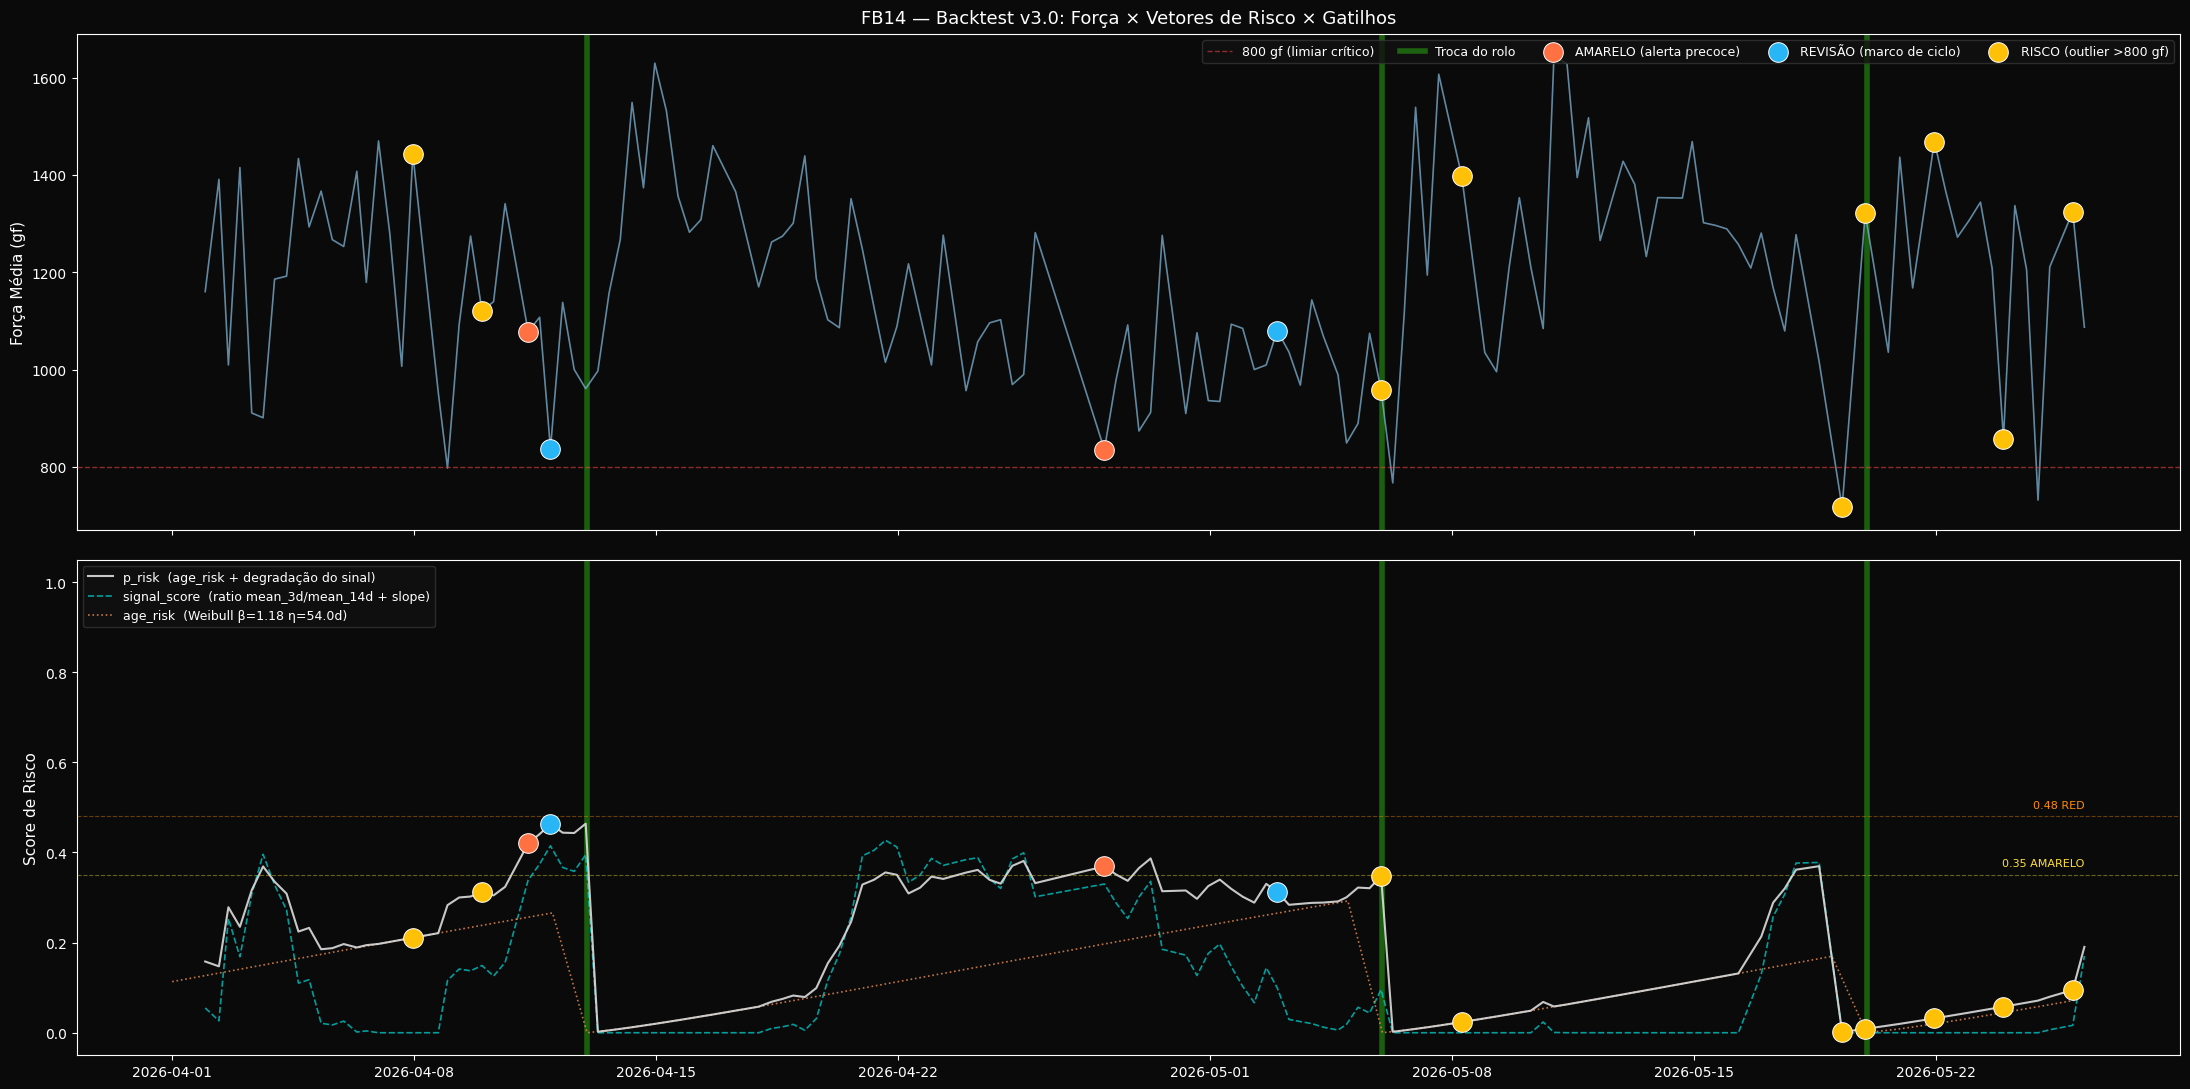

In [7]:
import bisect
import tempfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.trigger_engine import _weibull_age_risk

def force_utc(t):
    ts = pd.to_datetime(t)
    return ts.tz_localize('UTC') if ts.tz is None else ts.tz_convert('UTC')

inicio = force_utc('2026-04-01')
fim    = force_utc('2026-12-31 23:59:59')

if df.index.tz is None:
    df.index = df.index.tz_localize('UTC')
else:
    df.index = df.index.tz_convert('UTC')

df_filt = df.loc[inicio:fim].copy()

eventos_df['data_disparo'] = eventos_df['data_disparo'].apply(force_utc)
eventos_filt = eventos_df[
    (eventos_df['data_disparo'] >= inicio) & (eventos_df['data_disparo'] <= fim)
].copy()
troca_dates_filt = [t for t in troca_dates if inicio <= force_utc(t) <= fim]

# ── age_risk contínuo — Weibull CDF por dia ───────────────────────────────────
_tmp = Path(tempfile.mktemp(suffix='.json'))
_eng_ref = TriggerEngine(MAQUINA, _tmp)
_wb_beta, _wb_eta = _eng_ref.weibull_beta, _eng_ref.weibull_eta_d
if _tmp.exists(): _tmp.unlink()

_troca_sorted = sorted(force_utc(t) for t in troca_dates)

def _age_risk_at(ts):
    idx = bisect.bisect_right(_troca_sorted, ts) - 1
    if idx < 0: return np.nan
    return _weibull_age_risk((ts - _troca_sorted[idx]).days, _wb_beta, _wb_eta)

df_daily = df_filt.resample('1D').last()
df_daily['age_risk'] = [_age_risk_at(ts) for ts in df_daily.index]

# ── Paleta por gatilho (alinhada com os cards do Teams) ───────────────────────
mapa_cores = {
    'RISCO':       '#ffc107',   # âmbar   — outlier isolado (>800 gf, recupera)
    'REVISAO':     '#29b6f6',   # azul    — marco de ciclo
    'AMARELO':     '#ff7043',   # laranja — alerta precoce
    'CRITICO':     '#ff8c00',   # laranja escuro — degradação confirmada
    'EMERGENCIAL': '#f44336',   # vermelho — força crítica sustentada
    'RED':         '#ce93d8',   # roxo    — fim de vida útil
}
mapa_labels = {
    'RISCO':       'RISCO (outlier >800 gf)',
    'REVISAO':     'REVISÃO (marco de ciclo)',
    'AMARELO':     'AMARELO (alerta precoce)',
    'CRITICO':     'CRÍTICO (degradação confirmada)',
    'EMERGENCIAL': 'EMERGENCIAL (força crítica)',
    'RED':         'RED (fim de vida)',
}
cor_troca = '#39ff14'

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(22, 11), sharex=True)
fig.patch.set_facecolor('#0a0a0a')

# ═══════════════ Painel superior — Força de selagem ══════════════════════════
ax0 = axes[0]
ax0.set_facecolor('#0a0a0a')

ax0.plot(df_filt.index, df_filt['Media'],
         lw=1.2, color='#7fb3d4', alpha=0.75, zorder=2)
ax0.axhline(800, color='#ff4444', lw=1.0, ls='--', alpha=0.55, zorder=3,
            label='800 gf (limiar crítico)')

for j, t in enumerate(troca_dates_filt):
    ax0.axvline(force_utc(t), color=cor_troca, lw=4, alpha=0.35, zorder=1,
                label='Troca do rolo' if j == 0 else '')

for gat, grupo in eventos_filt.groupby('gatilho'):
    cor   = mapa_cores.get(gat, 'white')
    label = mapa_labels.get(gat, gat)
    idxs  = df_filt.index.get_indexer(grupo['data_disparo'], method='nearest')
    mask  = (idxs >= 0) & (idxs < len(df_filt))
    ax0.scatter(df_filt.index[idxs[mask]], df_filt.iloc[idxs[mask]]['Media'],
                color=cor, s=200, zorder=10, edgecolors='white', lw=0.7, label=label)

ax0.set_ylabel('Força Média (gf)', fontsize=11)
ax0.set_title('FB14 — Backtest v3.0: Força × Vetores de Risco × Gatilhos',
              fontsize=13, pad=8)
ax0.legend(loc='upper right', ncol=8, frameon=True,
           facecolor='#111', edgecolor='#333', fontsize=9)

# ═══════════════ Painel inferior — Vetores de risco ══════════════════════════
ax1 = axes[1]
ax1.set_facecolor('#0a0a0a')

ax1.plot(df_filt.index, df_filt['p_risk'],
         lw=1.5, color='#dddddd', alpha=0.9, zorder=4,
         label='p_risk  (age_risk + degradação do sinal)')
ax1.plot(df_filt.index, df_filt['signal_score'],
         lw=1.2, color='#00cfcf', alpha=0.75, ls='--', zorder=3,
         label='signal_score  (ratio mean_3d/mean_14d + slope)')
ax1.plot(df_daily.index, df_daily['age_risk'],
         lw=1.2, color='#ff9955', alpha=0.75, ls=':', zorder=3,
         label=f'age_risk  (Weibull β={_wb_beta:.2f} η={_wb_eta:.1f}d)')

ax1.axhline(0.48, color='#ff8c00', lw=0.8, ls='--', alpha=0.4, zorder=2)
ax1.axhline(0.35, color='#ffe033', lw=0.8, ls='--', alpha=0.4, zorder=2)
ax1.text(df_filt.index[-1], 0.495, '0.48 RED',      color='#ff8c00',
         fontsize=8, ha='right', va='bottom')
ax1.text(df_filt.index[-1], 0.365, '0.35 AMARELO',  color='#ffe033',
         fontsize=8, ha='right', va='bottom')

for t in troca_dates_filt:
    ax1.axvline(force_utc(t), color=cor_troca, lw=4, alpha=0.35, zorder=1)

for gat, grupo in eventos_filt.groupby('gatilho'):
    cor  = mapa_cores.get(gat, 'white')
    idxs = df_filt.index.get_indexer(grupo['data_disparo'], method='nearest')
    mask = (idxs >= 0) & (idxs < len(df_filt))
    ax1.scatter(df_filt.index[idxs[mask]], df_filt.iloc[idxs[mask]]['p_risk'],
                color=cor, s=200, zorder=10, edgecolors='white', lw=0.7)

ax1.set_ylabel('Score de Risco', fontsize=11)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper left', frameon=True, facecolor='#111',
           edgecolor='#333', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(hspace=0.06)
plt.show()

## Etapa D — Estado atual

In [8]:
from src.trigger_engine import compute_p_risk_snapshot

ultima_troca = troca_dates[-1]
hoje         = df.index.max().normalize()
age_days     = int((hoje.tz_convert('UTC') - pd.Timestamp(ultima_troca).tz_convert('UTC')).days)

state_atual  = Path('state_fb14.json')
engine_atual = TriggerEngine(MAQUINA, state_atual)

df_atual = df[df.index >= ultima_troca]
print(f'Última troca : {ultima_troca.date()}')
print(f'Avaliando em : {hoje.date()}')
print(f'Dados no ciclo atual : {len(df_atual)} linhas')

# ── Vida útil de referência ajustada ─────────────────────────────────────────
eta_bruto    = engine_atual.weibull_eta_d
vida_decay_w = engine_atual.vida_decay_w
eta_ajustado = engine_atual._compute_vida_ref_ajustada(troca_dates)

_ano = hoje.year
_duracoes = []
for i in range(1, len(troca_dates)):
    t_fim = pd.Timestamp(troca_dates[i]).tz_convert('UTC')
    if t_fim.year == _ano:
        dur = (t_fim - pd.Timestamp(troca_dates[i-1]).tz_convert('UTC')).total_seconds() / 86400.0
        if dur > 0:
            _duracoes.append(dur)
mean_vida_ano  = sum(_duracoes) / len(_duracoes) if _duracoes else eta_bruto
dias_restantes = max(0, int(round(eta_ajustado - age_days)))

print()
print('── Vida útil de referência (η ajustado) ────────────────────')
print(f'  η bruto (Weibull fit histórico)  : {eta_bruto:.1f} dias')
print(f'  Média dos ciclos {_ano}             : {mean_vida_ano:.1f} dias  ({len(_duracoes)} ciclo(s))')
print(f'  vida_decay_w                     : {vida_decay_w}')
print(f'  η ajustado  =  η − (η − média) × w  =  {eta_ajustado:.1f} dias')
print(f'  Dias em operação                 : {age_days} dias')
print(f'  Dias restantes estimados         : {dias_restantes} dias')

# ── Snapshot de indicadores ───────────────────────────────────────────────────
print()
print('── Snapshot de indicadores (engine v3) ────────────────────')
if df_atual.empty:
    print('  Ciclo atual sem dados — não é possível avaliar.')
else:
    snap = compute_p_risk_snapshot(df, ultima_troca.to_pydatetime(), hoje)
    _flags = {
        'cond_p_risk' : '✓ C1: p_risk ≥ limiar RED',
        'cond_signal' : '✓ C2: signal_score ≥ limiar',
        'cond_idade'  : '✓ C3: idade ≥ mínima',
        'cond_proj'   : '✓ C4: projeção 48h < 800 gf',
        'cond_critico': '✓ Força crítica confirmada',
        'cond_risco'  : '✓ Outlier isolado (recupera)',
    }
    for k, v in snap.items():
        flag = f'  {_flags[k]}' if k in _flags and v else ''
        print(f'  {k:<25}: {v}{flag}')

    print()
    eventos_hoje = engine_atual.evaluate(
        df,
        troca_date  = ultima_troca.to_pydatetime(),
        sp_client   = None,
        today       = hoje,
        troca_dates = troca_dates,
    )
    if eventos_hoje:
        print(f'  GATILHO(S) DISPARADO(S) ({len(eventos_hoje)}):')
        for ev in eventos_hoje:
            print(f'    [{ev.severidade}] {ev.gatilho}  '
                  f'evento_no_ciclo={ev.evento_no_ciclo}  '
                  f'dias_restantes={dias_restantes}')
            print(f'    {ev.mensagem}')
    else:
        print('  Nenhum gatilho disparado hoje — situação NORMAL.')

print()
print('── Estado persistido (state_fb14.json) ─────────────────────')
with open(state_atual) as f:
    print(json.dumps(json.load(f), indent=2))

Última troca : 2026-05-20
Avaliando em : 2026-05-26
Dados no ciclo atual : 16 linhas

── Vida útil de referência (η ajustado) ────────────────────
  η bruto (Weibull fit histórico)  : 54.0 dias
  Média dos ciclos 2026             : 25.5 dias  (6 ciclo(s))
  vida_decay_w                     : 0.8
  η ajustado  =  η − (η − média) × w  =  31.2 dias
  Dias em operação                 : 6 dias
  Dias restantes estimados         : 25 dias

── Snapshot de indicadores (engine v3) ────────────────────
  today                    : 2026-05-26
  age_days                 : 6
  mean_3d                  : 1145.1
  mean_7d                  : 1179.6
  mean_14d                 : 1224.1
  min_3d                   : 731.9
  mediana_3d               : 1207.5
  n_leituras_abaixo_800    : 1
  ratio_3_14               : 0.9354
  slope_7d                 : 6.3
  proj_48h                 : 1157.6
  age_risk                 : 0.0719
  sig_score                : 0.0387
  p_risk                   : 0.0952
  cond_p

## Etapa E — Escrever no SharePoint (opcional)

Executar somente quando `ESCREVER_SP = True` na célula de configuração.  
Requer `sharepoint.ev` com `SP_USER=` e `SP_PASS=`.

if not ESCREVER_SP:
    print('ESCREVER_SP=False -- pulando escrita no SharePoint.')
    print('Para ativar: set ESCREVER_SP = True na celula de configuracao.')
else:
    from src.sharepoint_methods import SharePointClient
    from dotenv import dotenv_values

    creds = dotenv_values('../sharepoint.ev')
    sp_user = creds.get('SP_USER')
    sp_pass = creds.get('SP_PASS')
    sp_url  = creds.get('SP_URL', 'https://kimberlyclark.sharepoint.com/Sites/H945')

    if not sp_user or not sp_pass:
        raise RuntimeError('Credenciais SP_USER/SP_PASS nao encontradas em sharepoint.ev')

    sp_client = SharePointClient(url=sp_url, username=sp_user, password=sp_pass)

    engine_sp = TriggerEngine(MAQUINA, Path('state_fb14.json'))
    eventos_sp = engine_sp.evaluate(
        df,
        troca_date=ultima_troca.to_pydatetime(),
        sp_client=sp_client,
        list_name=LIST_NAME,
        today=hoje,
    )

    if eventos_sp:
        print(f'{len(eventos_sp)} evento(s) escrito(s) na lista "{LIST_NAME}":')
        for ev in eventos_sp:
            print(f'  [{ev.severidade}] {ev.gatilho}  SP_ID={ev.sp_item_id}')
    else:
        print('Nenhum evento para escrever -- estado atual normal.')

## Resumo do backtest

In [9]:
if not eventos_df.empty:
    print('=' * 60)
    print('  RESUMO DO BACKTEST v3 — Todos os Gatilhos')
    print('=' * 60)
    n_ciclos = len(troca_dates) - 1
    cobertos = eventos_df['ciclo_id'].nunique()
    print(f'  Ciclos historicos avaliados : {n_ciclos}')
    print(f'  Total de eventos disparados : {len(eventos_df)}')
    print(f'  Ciclos com disparo          : {cobertos} / {n_ciclos}  ({cobertos/n_ciclos:.0%})')
    print()
    print('  Por tipo:')
    for (gat, sev), n in eventos_df.groupby(['gatilho','severidade']).size().items():
        print(f'    {gat:<14} [{sev}]  {n}')
    print()

    red_df = eventos_df[eventos_df['gatilho'] == 'RED']
    if not red_df.empty:
        primeiro_red = (
            red_df
            .sort_values('data_disparo')
            .groupby('ciclo_id', as_index=False)
            .first()
        )
        vals_ant = primeiro_red['antecedencia_d']
        vals_p   = primeiro_red['p_risk']
        print(f'  Antecedencia do 1o disparo RED:')
        print(f'    median = {vals_ant.median():.0f} dias')
        print(f'    min    = {vals_ant.min():.0f} dias')
        print(f'    max    = {vals_ant.max():.0f} dias')
        print()
        print(f'  p_risk no 1o disparo RED por ciclo:')
        print(f'    median = {vals_p.median():.3f}')
        print(f'    min    = {vals_p.min():.3f}')
        print(f'    max    = {vals_p.max():.3f}')
        print()

    todos_ciclos = set(range(len(troca_dates) - 1))
    ciclos_fire  = set(eventos_df['ciclo_id'].unique())
    ciclos_sil   = sorted(todos_ciclos - ciclos_fire)
    if ciclos_sil:
        print(f'  Ciclos silenciosos (sem disparo): {ciclos_sil}')
        print('  (ciclos curtos = trocas preventivas — comportamento esperado)')
    print('=' * 60)
else:
    print('Nenhum evento disparado no backtest.')

  RESUMO DO BACKTEST v3 — Todos os Gatilhos
  Ciclos historicos avaliados : 14
  Total de eventos disparados : 214
  Ciclos com disparo          : 13 / 14  (93%)

  Por tipo:
    AMARELO        [MEDIA]  57
    CRITICO        [ALTA]  42
    EMERGENCIAL    [CRITICA]  40
    RED            [ALTA]  7
    REVISAO        [INFO]  19
    RISCO          [INFO]  49

  Antecedencia do 1o disparo RED:
    median = 44 dias
    min    = 21 dias
    max    = 68 dias

  p_risk no 1o disparo RED por ciclo:
    median = 0.650
    min    = 0.612
    max    = 0.687

  Ciclos silenciosos (sem disparo): [0, 4]
  (ciclos curtos = trocas preventivas — comportamento esperado)


## Etapa F — Envio retroativo: backtest 2026 → SharePoint

Envia todos os eventos de `eventos_filt` (2026) para a lista `Gatilhos_Selagem`,
gerando o `TeamsPayload` (Adaptive Card) para cada alerta.

Pré-requisito: `sharepoint.ev` com `SP_USER=` e `SP_PASS=` na raiz do projeto.

In [10]:
eventos_filt['data_disparo'] = pd.to_datetime(eventos_filt['data_disparo'])

eventos_filt = eventos_filt[
    (eventos_filt['data_disparo'].dt.year == 2026) &
    (eventos_filt['data_disparo'].dt.month >= 4)
]

eventos_filt = eventos_filt.sort_values(by='data_disparo', ascending=True)
eventos_filt

,ciclo_id,troca_ini,troca_fim,data_disparo,gatilho,severidade,idade_dias,evento_no_ciclo,p_risk,signal_score,age_risk,slope_7d,mean_3d,proj_48h,antecedencia_d
201,11,2026-03-23,2026-04-13,2026-04-08 00:00:00+00:00,RISCO,INFO,16,1,NaN,NaN,NaN,NaN,797.7,NaN,5.0
202,11,2026-03-23,2026-04-13,2026-04-10 00:00:00+00:00,RISCO,INFO,18,2,NaN,NaN,NaN,NaN,797.7,NaN,3.0
203,11,2026-03-23,2026-04-13,2026-04-11 00:00:00+00:00,AMARELO,MEDIA,19,0,0.4471,0.4006,NaN,-42.2,797.7,989.800000,2.0
204,11,2026-03-23,2026-04-13,2026-04-12 00:00:00+00:00,REVISAO,INFO,20,0,0.4521,0.3901,NaN,-43.7,837.1,1060.841577,1.0
205,12,2026-04-13,2026-05-06,2026-04-28 00:00:00+00:00,AMARELO,MEDIA,15,0,0.3415,0.2760,NaN,-22.2,835.7,958.400000,8.0
206,12,2026-04-13,2026-05-06,2026-05-03 00:00:00+00:00,REVISAO,INFO,20,0,0.2806,0.0307,NaN,18.0,909.8,965.104280,3.0
207,13,2026-05-06,2026-05-20,2026-05-06 00:00:00+00:00,RISCO,INFO,0,1,NaN,NaN,NaN,NaN,767.2,NaN,14.0
208,13,2026-05-06,2026-05-20,2026-05-08 00:00:00+00:00,RISCO,INFO,2,2,NaN,NaN,NaN,NaN,767.2,NaN,12.0
209,13,2026-05-06,2026-05-20,2026-05-19 00:00:00+00:00,RISCO,INFO,13,3,NaN,NaN,NaN,NaN,717.0,NaN,1.0
210,14,2026-05-20,None,2026-05-20 00:00:00+00:00,RISCO,INFO,0,1,NaN,NaN,NaN,NaN,717.0,NaN,NaN


In [11]:
from dotenv import dotenv_values
from src.sharepoint_methods import SharePointClient
from src.card_formatter import build_alert_card
import json, numpy as np

creds     = dotenv_values('../sharepoint.ev')
LIST_NAME = 'Gatilhos_Selagem'
BATCH_SIZE = 10

_ACAO = {
    'RISCO':       ('Ir verificar no local — analisar última amostra e identificar causa '
                    'da força extremamente baixa. '
                    'Se 2+ leituras abaixo de 800 N nas próximas 72h, o sistema escalará para CRÍTICO.'),
    'CRITICO':     ('Análise aprofundada e planejamento de troca do rolo maintacker.'),
    'EMERGENCIAL': ('Risco iminente de retenção — acionar troca imediata do rolo maintacker.'),
    'RED':         ('Programar inspeção preventiva do rolo maintacker. '
                    'Verificar força de selagem no próximo turno. '
                    'Registrar: OK / Troca programada / Troca imediata.'),
    'AMARELO':     ('Monitorar força de selagem diariamente. '
                    'Incluir troca do maintacker no próximo plano de manutenção preventiva.'),
    'REVISAO':     ('Revisar tendência de força no gráfico. '
                    'Se forças abaixo de 900 N ou tendência negativa persistente, '
                    'antecipar inspeção do rolo.'),
}

_NOVOS_NIVEIS = {'RISCO', 'CRITICO', 'EMERGENCIAL'}

def _nan_to_none(x):
    if x is None: return None
    try: return None if np.isnan(float(x)) else float(x)
    except (TypeError, ValueError): return None

def _build_retroativo_json(row: dict, acao: str) -> str:
    """JSON estruturado v3.0 para envio retroativo (campos disponíveis no backtest)."""
    antecedencia = int(row.get('antecedencia_d', 0))
    d = {
        'nivel':             row['gatilho'],
        'evento_no_ciclo':   int(row.get('evento_no_ciclo', 0)),
        'dias_operacao':     int(row['idade_dias']),
        'eta_ajustado_dias': int(row['idade_dias']) + antecedencia,
        'dias_restantes':    antecedencia,
        'acao':              acao,
    }
    forca = _nan_to_none(row.get('mean_3d'))
    proj  = _nan_to_none(row.get('proj_48h'))
    if row['gatilho'] == 'RISCO':
        d['data_evento'] = str(row['data_disparo'])
        if forca: d['forca_gf'] = int(round(forca))
    elif row['gatilho'] == 'CRITICO':
        d['data_evento'] = str(row['data_disparo'])
        if forca: d['forca_min_ultima_amostra_gf'] = int(round(forca))
        if proj:  d['forca_projetada_gf'] = int(round(proj))
        d['p_risk'] = round(float(row.get('p_risk', 0) or 0), 2)
    elif row['gatilho'] == 'EMERGENCIAL':
        if forca: d['forca_min_ultima_amostra_gf'] = int(round(forca))
        if proj:  d['forca_projetada_48h_gf'] = int(round(proj))
        d['p_risk'] = round(float(row.get('p_risk', 0) or 0), 2)
    return json.dumps(d, ensure_ascii=False)

sp = SharePointClient("https://kimberlyclark.sharepoint.com/Sites/H945",
                      creds['SP_USER'], creds['SP_PASS'])
print('SharePoint conectado.')

df_existentes   = sp.query_large_list(LIST_NAME)
titles_exist    = set(df_existentes['Title'].dropna()) if 'Title' in df_existentes.columns else set()
print(f'Itens já na lista      : {len(titles_exist)}')
print(f'Eventos 2026 no backtest: {len(eventos_filt)}')

itens   = []
pulados = []
for _, ev in eventos_filt.iterrows():
    gatilho = ev['gatilho']
    data_ts = ev['data_disparo']
    title   = f"{MAQUINA} | {gatilho} | {pd.Timestamp(data_ts).strftime('%Y-%m-%d')}"

    if title in titles_exist:
        pulados.append(title)
        continue

    acao = _ACAO.get(gatilho, 'Avaliar situação com equipe de manutenção.')

    if gatilho in _NOVOS_NIVEIS:
        payload = _build_retroativo_json(ev.to_dict(), acao)
    else:
        payload = build_alert_card(
            maquina          = MAQUINA,
            gatilho          = gatilho,
            idade_dias       = int(ev['idade_dias']),
            p_risk           = float(ev['p_risk']),
            slope_7d         = _nan_to_none(ev['slope_7d']),
            forca_min_3d     = _nan_to_none(ev['mean_3d']),
            proj_48h         = _nan_to_none(ev['proj_48h']),
            acao_recomendada = acao,
            data_disparo     = pd.Timestamp(data_ts).to_pydatetime(),
        )
    itens.append({'Title': title, 'Maquina': MAQUINA, 'TeamsPayload': payload})

print(f'Já existentes (pulados): {len(pulados)}')
print(f'Novos a inserir        : {len(itens)}')

if not itens:
    print('Nenhum item novo — lista já está atualizada.')
else:
    ids_criados = []
    for i in range(0, len(itens), BATCH_SIZE):
        lote = itens[i : i + BATCH_SIZE]
        ids  = sp.insert_list_item(LIST_NAME, lote)
        ids_criados.extend(ids)
        datas = [item['Title'].split(' | ')[-1] for item in lote]
        print(f'  Lote {i//BATCH_SIZE+1:02d}: {len(lote)} itens '
              f'({datas[0]} → {datas[-1]})  IDs: {ids}')
    print(f'\n✓ Total inserido: {len([x for x in ids_criados if x])} / {len(itens)}')

SharePoint conectado.
Itens já na lista      : 26
Eventos 2026 no backtest: 13

ValueError: cannot convert float NaN to integer

Error found at line 35 in cell 11.


Button(description='Click to show stack trace', layout=Layout(height='auto', width='auto'), style=ButtonStyle(…